In [1]:
import pandas as pd

df = pd.read_csv("UCI_HAR_Dataset.csv")
print(df.head())

print("Shape:", df.shape)
print(df.columns)
print(df.isnull().sum().sum())

   subject_id  activity_id activity_name set_type  tBodyAcc-mean()-X  \
0           1            5      STANDING    train           0.288585   
1           1            5      STANDING    train           0.278419   
2           1            5      STANDING    train           0.279653   
3           1            5      STANDING    train           0.279174   
4           1            5      STANDING    train           0.276629   

   tBodyAcc-mean()-Y  tBodyAcc-mean()-Z  tBodyAcc-std()-X  tBodyAcc-std()-Y  \
0          -0.020294          -0.132905         -0.995279         -0.983111   
1          -0.016411          -0.123520         -0.998245         -0.975300   
2          -0.019467          -0.113462         -0.995380         -0.967187   
3          -0.026201          -0.123283         -0.996091         -0.983403   
4          -0.016570          -0.115362         -0.998139         -0.980817   

   tBodyAcc-std()-Z  ...  fBodyBodyGyroJerkMag-meanFreq()  \
0         -0.913526  ...       

In [2]:
from sklearn.preprocessing import StandardScaler

train_df = df[df["set_type"] == "train"]
test_df = df[df["set_type"] == "test"]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
drop_cols = [
    "subject_id",
    "activity_id",
    "activity_name",
    "set_type"
]

X_train = train_df.drop(columns=drop_cols).values
X_test = test_df.drop(columns=drop_cols).values

y_train = train_df["activity_id"].values - 1
y_test = test_df["activity_id"].values - 1

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Normalization complete")

Train shape: (7352, 565)
Test shape: (2947, 565)
X_train shape: (7352, 561)
X_test shape: (2947, 561)
y_train shape: (7352,)
y_test shape: (2947,)
Normalization complete


In [3]:
X_train = X_train.reshape(-1, 51, 11)
X_test = X_test.reshape(-1, 51, 11)

print("New X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

print("Single sample shape:", X_train[0].shape)

New X_train shape: (7352, 51, 11)
New X_test shape: (2947, 51, 11)
Single sample shape: (51, 11)


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader

class HARDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

train_dataset = HARDataset(X_train, y_train)
test_dataset = HARDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

for X_batch, y_batch in train_loader:

    print("Batch X shape:", X_batch.shape)
    print("Batch y shape:", y_batch.shape)

    break

Train batches: 115
Test batches: 47
Batch X shape: torch.Size([64, 51, 11])
Batch y shape: torch.Size([64])


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional

model = Sequential()

model.add(
    Bidirectional(
        LSTM(
            128,
            return_sequences=False
        ),
        input_shape=(51, 11)
    )
)

model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 256)            │       143,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,198 (625.77 KB)

 Trainable params: 160,198 (625.77 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 23s 201ms/step - accuracy: 0.7116 - loss: 0.6485 - val_accuracy: 0.8409 - val_loss: 0.4241
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 153ms/step - accuracy: 0.8701 - loss: 0.3208 - val_accuracy: 0.8558 - val_loss: 0.3288
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - accuracy: 0.9090 - loss: 0.2217 - val_accuracy: 0.8439 - val_loss: 0.3552
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 154ms/step - accuracy: 0.9366 - loss: 0.1667 - val_accuracy: 0.8985 - val_loss: 0.2838
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 155ms/step - accuracy: 0.9442 - loss: 0.1410 - val_accuracy: 0.8965 - val_loss: 0.3049
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 20s 173ms/step - accuracy: 0.9525 - loss: 0.1246 - val_accuracy: 0.9128 - val_loss: 0.2358
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.9648 - loss: 0.0934 - val_accuracy: 0.9036 - val_loss: 0.2705
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.9629 - loss: 0

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.9094 - loss: 0.4078
Test Accuracy: 0.9093993902206421
Test Loss: 0.40781745314598083


In [10]:
import numpy as np
predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


93/93 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step
                    precision    recall  f1-score   support

           WALKING       0.82      0.95      0.88       496
  WALKING_UPSTAIRS       0.92      0.81      0.86       471
WALKING_DOWNSTAIRS       0.93      0.89      0.91       420
           SITTING       0.93      0.89      0.91       491
          STANDING       0.88      0.94      0.91       532
            LAYING       1.00      0.97      0.98       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



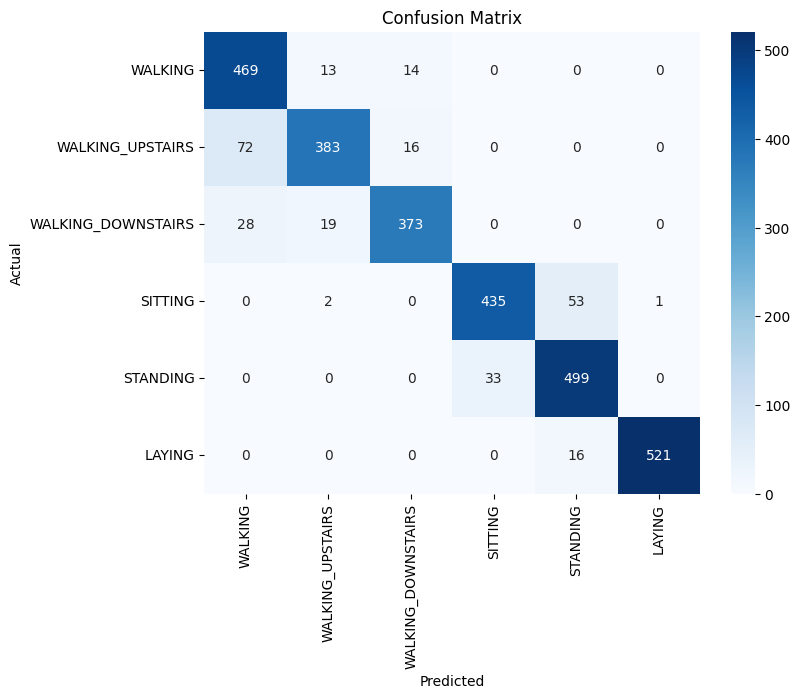

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)

predicted_classes = np.argmax(y_pred, axis=1)

activity_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=activity_names
    )
)


cm = confusion_matrix(y_test, predicted_classes)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=activity_names,
    yticklabels=activity_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()